# **PBL-I: Geomagnetic Storm Classification Analysis**



This notebook presents the visualization, performance analysis,
error analysis and interpretation of the XGBoost geomagnetic
storm classification results.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
classification_metrics = pd.read_csv("classification_metrics.csv")
test_metrics = pd.read_csv("test_metrics.csv")
predictions = pd.read_csv("classification_predictions.csv")

print("Classification Metrics:")
display(classification_metrics)

print("\nTest Metrics:")
display(test_metrics)

print("\nPredictions:")
display(predictions.head())

Classification Metrics:


,Unnamed: 0,precision,recall,f1-score,support
0,0,1.000000,0.942663,0.970485,2058.000000
1,1,0.000000,0.000000,0.000000,0.000000
2,accuracy,0.942663,0.942663,0.942663,0.942663
3,macro avg,0.500000,0.471331,0.485243,2058.000000
4,weighted avg,1.000000,0.942663,0.970485,2058.000000



Test Metrics:


,Unnamed: 0,precision,recall,f1-score,support
0,0,0.965074,0.826772,0.890585,1905.000000
1,1,0.225352,0.627451,0.331606,153.000000
2,accuracy,0.811953,0.811953,0.811953,0.811953
3,macro avg,0.595213,0.727111,0.611096,2058.000000
4,weighted avg,0.910080,0.811953,0.849028,2058.000000



Predictions:


,period,hour,dst,storm_pred,storm_proba
0,train_a,433 days 20:00:00,3,0,0.001370
1,train_a,433 days 21:00:00,5,0,0.000957
2,train_a,433 days 22:00:00,7,0,0.000866
3,train_a,433 days 23:00:00,12,0,0.001586
4,train_a,434 days 00:00:00,9,0,0.001694


In [11]:
print("Classification Test Results")

print("Accuracy   : 81.20%")
print("Precision  : 22.54%")
print("Recall     : 62.75%")
print("F1-score   : 33.16%")

Classification Test Results
Accuracy   : 81.20%
Precision  : 22.54%
Recall     : 62.75%
F1-score   : 33.16%


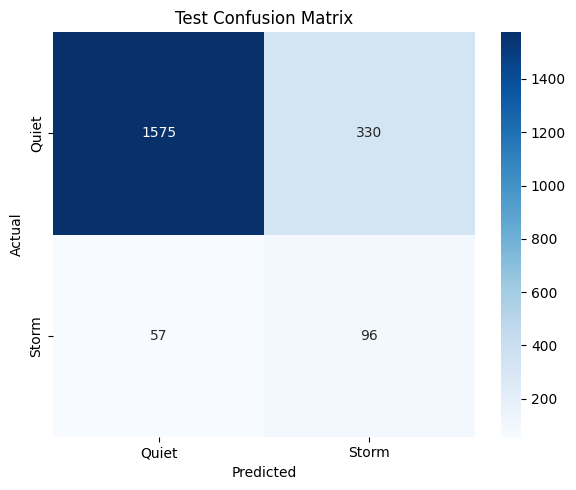

In [12]:
cm = np.array([
    [1575, 330],
    [57, 96]
])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Quiet", "Storm"],
    yticklabels=["Quiet", "Storm"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

### **Confusion Matrix Interpretation**

- True Negative (TN) = 1575
- False Positive (FP) = 330
- False Negative (FN) = 57
- True Positive (TP) = 96

The model correctly detected 96 out of 153 actual storm events.
It missed 57 storms and incorrectly classified 330 quiet observations
as storms.

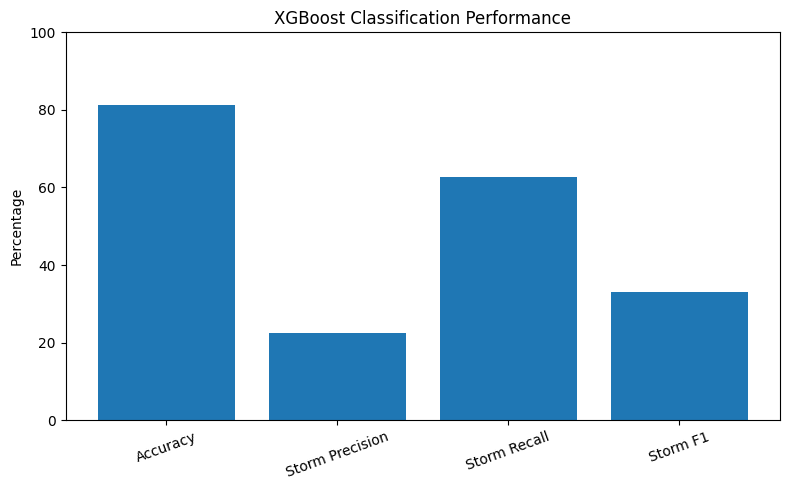

In [13]:
metrics = {
    "Accuracy": 81.20,
    "Storm Precision": 22.54,
    "Storm Recall": 62.75,
    "Storm F1": 33.16
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Percentage")
plt.title("XGBoost Classification Performance")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

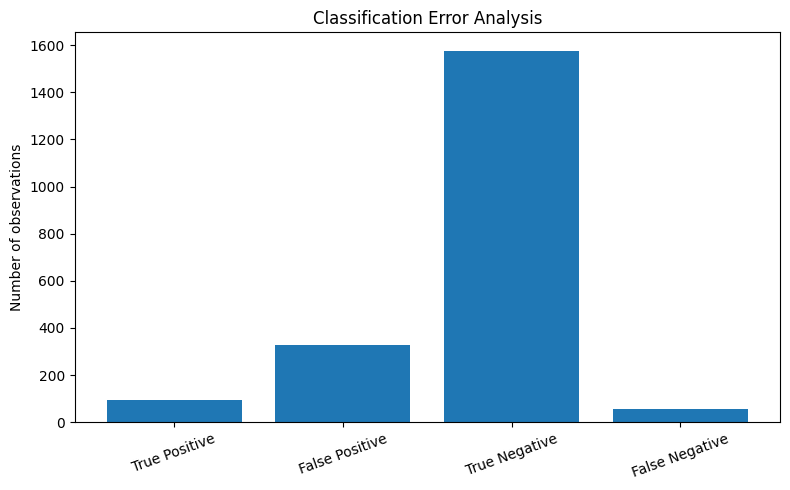

In [14]:
errors = {
    "True Positive": 96,
    "False Positive": 330,
    "True Negative": 1575,
    "False Negative": 57
}

plt.figure(figsize=(8,5))
plt.bar(errors.keys(), errors.values())
plt.ylabel("Number of observations")
plt.title("Classification Error Analysis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

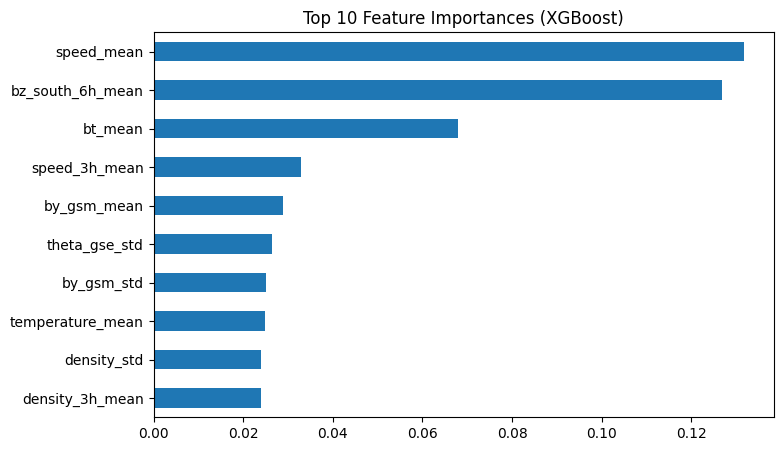

In [15]:
from IPython.display import Image, display

display(Image(filename="feature_importance.png"))

### Feature Importance

The most influential features were:

1. speed_mean
2. bz_south_6h_mean
3. bt_mean
4. speed_3h_mean
5. by_gsm_mean

The feature importance indicates which variables contributed most
to the model's predictions. It does not establish causation.

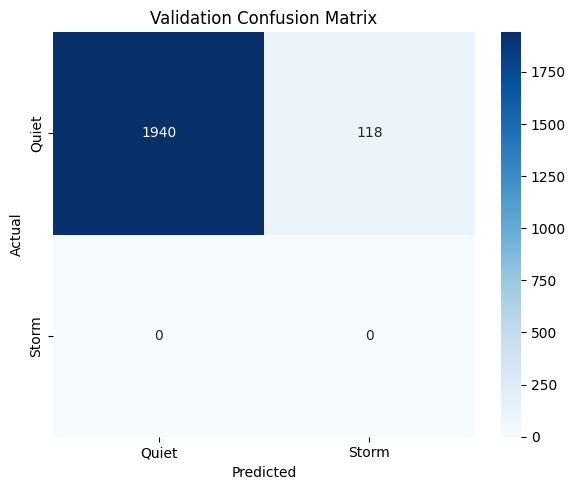

In [16]:
validation_cm = np.array([
    [1940, 118],
    [0, 0]
])

plt.figure(figsize=(6,5))
sns.heatmap(
    validation_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Quiet", "Storm"],
    yticklabels=["Quiet", "Storm"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### **Validation Limitation**

The validation dataset contains zero actual storm events.
Its minimum Dst value is -49 nT, while the storm threshold is
Dst ≤ -50 nT.

Therefore, the validation accuracy of 94.27% does not provide
a meaningful evaluation of storm-detection performance.

The test set, which contains 153 actual storm events, provides
the more informative classification evaluation.

## **Conclusion**

The XGBoost classifier achieved 81.20% accuracy on the test set.

It correctly detected 96 of 153 actual storms, giving a storm recall
of 62.75%. However, 330 quiet observations were incorrectly classified
as storms, resulting in a storm precision of 22.54%.

The validation period contained no actual storms, so its 94.27%
accuracy should be interpreted cautiously.

The most influential features included speed_mean,
bz_south_6h_mean and bt_mean.

Regression results are handled separately by the regression team member.